# Stokes coefficients comparison

In [ ]:
# Ensure that changes in imported module (gravann most importantly) are autoreloaded
%load_ext autoreload
%autoreload 2

import os

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torchquad as tquad
from mascon_cube import geodesynet
from mascon_cube.constants import GROUND_TRUTH_DIR, OUTPUT_DIR
from mascon_cube.data.mascon_model import MasconModel
from mascon_cube.data.mesh import get_mesh, is_outside_torch, unpack_triangle_mesh
from mascon_cube.data.stokes import combine_stokes_coefficients, mascon2stokes
from matplotlib import pyplot as plt
from torch import nn
from tqdm import tqdm

In [2]:
torch.manual_seed(42)
np.random.seed(42)
device = "cuda"

In [3]:
asteroids = [f.name for f in GROUND_TRUTH_DIR.iterdir() if f.is_dir()]

# Compute stokes

## Compute stokes coefficients for ground-truth models

In [ ]:
for asteroid in tqdm(asteroids):
    model = MasconModel(asteroid, device=device)
    gt_stokes = mascon2stokes(model.coords, model.masses, r0=1, degree=7, order=7)
    gt_stokes = combine_stokes_coefficients(gt_stokes[0], gt_stokes[1])
    with open(GROUND_TRUTH_DIR / asteroid / "stokes.npy", "wb") as f:
        np.save(f, gt_stokes)

## Compute stokes coefficients for mascon cubes

In [ ]:
for asteroid in tqdm(asteroids):
    cube = torch.load(OUTPUT_DIR / "mascon_cube" / asteroid / "model.pt", weights_only=False)
    cube_stokes = mascon2stokes(cube.coords, cube.masses, r0=1, degree=7, order=7)
    cube_stokes = combine_stokes_coefficients(cube_stokes[0], cube_stokes[1])
    with open(OUTPUT_DIR / "mascon_cube" / asteroid / "stokes.npy", "wb") as f:
        np.save(f, cube_stokes)


## Compute stokes coefficients for geodesynets

In [ ]:
tquad.set_up_backend("torch")
# We construct the vecotrized Legendre associated polynomials
P = geodesynet.legendre_factory_torch(n=16)
# Declare an integrator
quad = tquad.Trapezoid()
os.environ["TORCH_DEVICE"] = "cuda:0"

In [ ]:
for asteroid in tqdm(asteroids):
    encoding = geodesynet.direct_encoding()
    net = geodesynet.init_network(encoding, n_neurons=100, model_type="siren", activation=nn.Tanh()).to("cuda:0")
    net.load_state_dict(torch.load(OUTPUT_DIR / "geodesynet" / asteroid / "model.pt"))
    net = net.to("cuda:0")
    with open(OUTPUT_DIR / "geodesynet" / asteroid / "c.txt", "r") as f:
        c = f.readline()
    c = float(c)

    uniform_model = MasconModel(asteroid, device="cpu", uniform=True)
    uniform_density = uniform_model.get_average_density()

    mesh_vertices, mesh_triangles = get_mesh(asteroid)
    triangles = unpack_triangle_mesh(mesh_vertices, mesh_triangles, "cuda")

    def mass(x):
        result = net(x) * c
        mask = is_outside_torch(x, triangles)
        result[mask] = 0
        mask = torch.bitwise_not(mask)
        result[mask] += uniform_density
        return result

    M = quad.integrate(mass, dim=3, N=300000, integration_domain=[[-1, 1], [-1, 1], [-1, 1]])

    stokesC_gann = np.zeros((8, 8))
    for l in range(8):
        for m in range(8):
            if m > l:
                continue
            stokesC_gann[l][m] = quad.integrate(
                lambda x, l=l, m=m, P=P, net=mass, R0=1: geodesynet.Clm(x, net, l, m, R0, P),
                dim=3,
                N=310000,
                integration_domain=[[-1, 1], [-1, 1], [-1, 1]],
            )
            stokesC_gann[l][m] = stokesC_gann[l][m] / M * geodesynet.constant_factors(l, m)

    stokesS_gann = np.zeros((8, 8))

    for l in range(8):
        for m in range(8):
            if m > l:
                continue
            stokesS_gann[l][m] = quad.integrate(
                lambda x, l=l, m=m, P=P, net=mass, R0=1: geodesynet.Slm(x, net, l, m, R0, P),
                dim=3,
                N=300000,
                integration_domain=[[-1, 1], [-1, 1], [-1, 1]],
            )
            stokesS_gann[l][m] = stokesS_gann[l][m] / M * geodesynet.constant_factors(l, m)

    geodesynet_stokes = combine_stokes_coefficients(stokesC_gann, stokesS_gann)
    with open(OUTPUT_DIR / "geodesynet" / asteroid / "stokes.npy", "wb") as f:
        np.save(f, geodesynet_stokes)

# Compare stokes

In [7]:
def create_dataframe(asteroids):
    df = []
    for asteroid in asteroids:
        with open(GROUND_TRUTH_DIR / asteroid / "stokes.npy", "rb") as f:
            gt_stokes = np.load(f)
        with open(OUTPUT_DIR / "geodesynet" / asteroid / "stokes.npy", "rb") as f:
            net_stokes = np.load(f)
        with open(OUTPUT_DIR / "mascon_cube" / asteroid / "stokes.npy", "rb") as f:
            cube_stokes = np.load(f)
        cube_error = np.abs(gt_stokes - cube_stokes)
        net_error = np.abs(gt_stokes - net_stokes)
        cube_error_rel = np.abs(gt_stokes - cube_stokes) / (np.abs(gt_stokes) + 1e-16)
        net_error_rel = np.abs(gt_stokes - net_stokes) / (np.abs(gt_stokes) + 1e-16)
        for stoke, error, error_rel in zip(cube_stokes.flatten(), cube_error.flatten(), cube_error_rel.flatten()):
            df.append({"asteroid": asteroid, "stoke": stoke, "error": error, "error_rel": error_rel, "model": "cube"})
        for stoke, error, error_rel in zip(net_stokes.flatten(), net_error.flatten(), net_error_rel.flatten()):
            df.append({"asteroid": asteroid, "stoke": stoke, "error": error, "error_rel": error_rel, "model": "net"})
    return pd.DataFrame(df)


In [8]:
df = create_dataframe(asteroids)

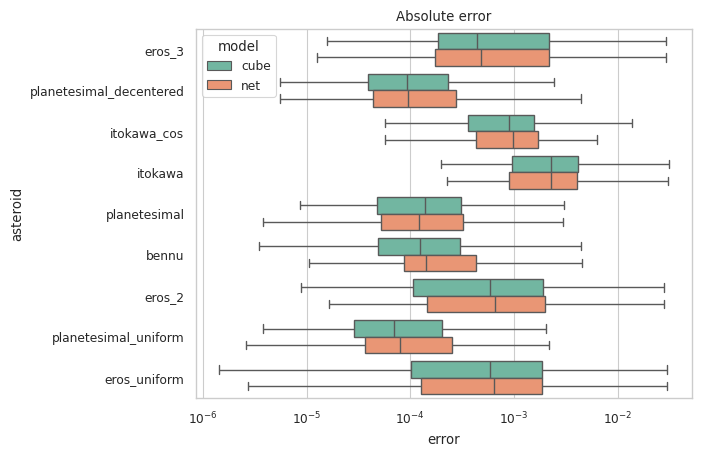

In [10]:
sns.set_theme()
sns.set_style("whitegrid")
sns.set_context("paper")

sns.boxplot(data=df, y="asteroid", x="error", hue="model", showfliers=False, palette="Set2", orient="h", log_scale=True)
plt.title("Absolute error")
plt.show()